# 3.2.2 Analytical Example: Histogram Equalization

## Given
- Image: 3-bit image
- Number of intensity levels, L = 8
- Gray levels: 0 to 7
- Image size: 64 × 64
- Total pixels, N = 4096

Formula:

sk = (L - 1) × CDF(rk)

In [9]:
from google.colab import files

uploaded = files.upload()

Saving image.png.png to image.png (1).png



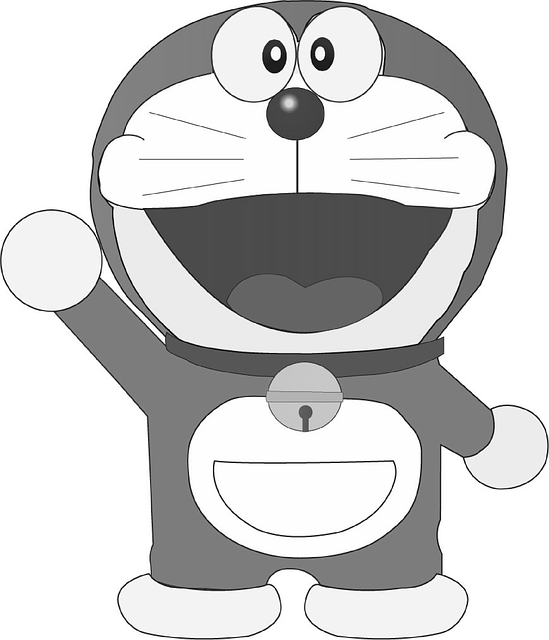
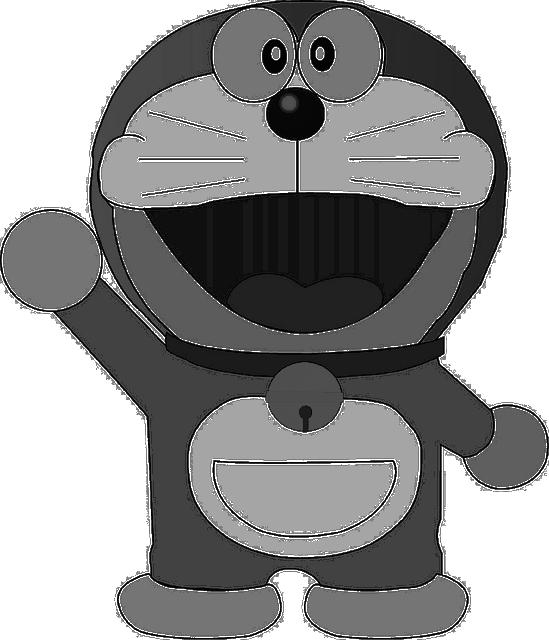
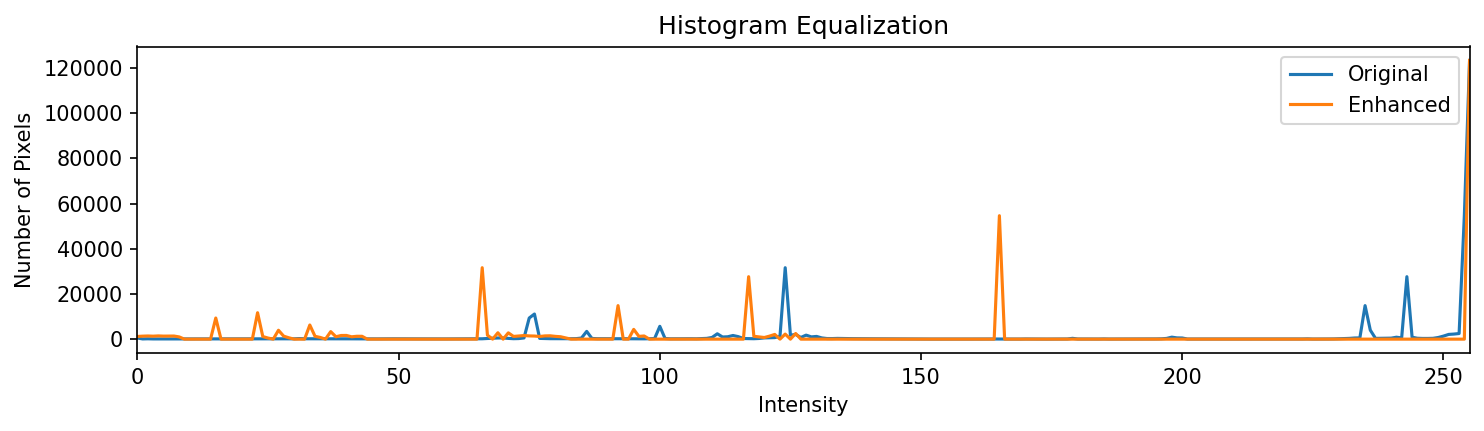

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import base64

# ==========================================
# READ UPLOADED IMAGE
# ==========================================

filename = list(uploaded.keys())[0]

image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Image not found!")
else:

    # ==========================================
    # HISTOGRAM EQUALIZATION
    # ==========================================

    enhanced = cv2.equalizeHist(image)

    # ==========================================
    # Convert images to Base64
    # ==========================================

    def image_to_base64(img):

        _, buffer = cv2.imencode(".png", img)

        return base64.b64encode(buffer).decode("utf-8")

    original_b64 = image_to_base64(image)
    enhanced_b64 = image_to_base64(enhanced)

    # ==========================================
    # HISTOGRAM
    # ==========================================

    original_hist = cv2.calcHist(
        [image], [0], None, [256], [0, 256]
    ).flatten()

    enhanced_hist = cv2.calcHist(
        [enhanced], [0], None, [256], [0, 256]
    ).flatten()

    # ==========================================
    # CREATE HISTOGRAM IMAGE
    # ==========================================

    plt.figure(figsize=(10, 3))

    plt.plot(
        original_hist,
        linewidth=1.5,
        label="Original"
    )

    plt.plot(
        enhanced_hist,
        linewidth=1.5,
        label="Enhanced"
    )

    plt.xlim(0, 255)
    plt.xlabel("Intensity")
    plt.ylabel("Number of Pixels")
    plt.title("Histogram Equalization")

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        "histogram.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()

    # ==========================================
    # Convert histogram to Base64
    # ==========================================

    with open("histogram.png", "rb") as f:
        histogram_b64 = base64.b64encode(f.read()).decode("utf-8")

    # ==========================================
    # INTERACTIVE COMPARISON
    # ==========================================

    html = f"""

    <style>

    .container {{
        width: 850px;
        margin: auto;
        font-family: Arial, sans-serif;
    }}

    .comparison {{
        position: relative;
        width: 850px;
        height: 500px;
        overflow: hidden;
        border-radius: 12px;
        background: #eee;
        box-shadow: 0 4px 15px rgba(0,0,0,0.15);
    }}

    .comparison img {{
        position: absolute;
        width: 100%;
        height: 100%;
        object-fit: contain;
        background: white;
    }}

    /* ORIGINAL IMAGE - LEFT */
    .original {{
        z-index: 1;
    }}

    /* ENHANCED IMAGE - RIGHT */
    .enhanced {{
        z-index: 2;
        clip-path: inset(0 0 0 50%);
    }}

    /* LABELS */

    .label {{
        position: absolute;
        top: 25px;
        padding: 10px 18px;
        background: rgba(255,255,255,0.92);
        border-radius: 8px;
        font-size: 20px;
        font-weight: bold;
        z-index: 5;
    }}

    .original-label {{
        left: 25px;
        color: #5d6f86;
    }}

    .enhanced-label {{
        right: 25px;
        color: #24334a;
    }}

    /* SLIDER LINE */

    .slider-line {{
        position: absolute;
        z-index: 10;
        top: 0;
        bottom: 0;
        left: 50%;
        width: 5px;
        background: white;
        box-shadow: 0 0 8px rgba(0,0,0,0.35);
        transform: translateX(-50%);
        pointer-events: none;
    }}

    /* SLIDER BUTTON */

    .slider-button {{
        position: absolute;
        z-index: 11;
        top: 50%;
        left: 50%;
        width: 52px;
        height: 52px;
        background: white;
        border-radius: 50%;
        transform: translate(-50%, -50%);
        box-shadow: 0 3px 12px rgba(0,0,0,0.25);

        display: flex;
        align-items: center;
        justify-content: center;

        font-size: 24px;
        color: #3c8d78;

        cursor: ew-resize;
        user-select: none;
    }}

    .scale {{
        display: flex;
        justify-content: space-between;
        margin-top: 5px;
        color: #607080;
        font-size: 13px;
    }}

    .description {{
        text-align: center;
        margin: 8px;
        font-size: 16px;
        color: #34495e;
    }}

    .histogram {{
        margin-top: 20px;
        text-align: center;
    }}

    .histogram img {{
        width: 850px;
        border-radius: 8px;
    }}

    .info {{
        text-align: center;
        margin-top: 15px;
        font-size: 17px;
        color: #34495e;
    }}

    </style>


    <div class="container">

        <div class="comparison" id="comparison">

            <!-- ORIGINAL IMAGE -->
            <img
                class="original"
                src="data:image/png;base64,{original_b64}"
            >

            <!-- ENHANCED IMAGE -->
            <img
                class="enhanced"
                id="enhanced"
                src="data:image/png;base64,{enhanced_b64}"
            >

            <!-- LABELS -->

            <div class="label original-label">
                Original: Low Contrast
            </div>

            <div class="label enhanced-label">
                Enhanced: High Contrast
            </div>

            <!-- SLIDER -->

            <div class="slider-line" id="line"></div>

            <div class="slider-button" id="button">
                ↔
            </div>

        </div>


        <div class="scale">
            <span>0 (Black)</span>
            <span>127 (Gray)</span>
            <span>255 (White)</span>
        </div>


        <div class="description">
            Drag the slider to compare Original and Enhanced images
        </div>


        <div class="histogram">

            <img
                src="data:image/png;base64,{histogram_b64}"
            >

        </div>


        <div class="info">

            <b>Histogram Equalization</b><br>

            Pixels are redistributed across the intensity range
            to improve image contrast.

        </div>

    </div>


    <script>

    const comparison = document.getElementById("comparison");
    const enhanced = document.getElementById("enhanced");
    const line = document.getElementById("line");
    const button = document.getElementById("button");

    let dragging = false;


    function moveSlider(x) {{

        const rect = comparison.getBoundingClientRect();

        let position = ((x - rect.left) / rect.width) * 100;

        position = Math.max(0, Math.min(100, position));


        /*
        LEFT  = ORIGINAL
        RIGHT = ENHANCED
        */

        enhanced.style.clipPath =
            `inset(0 0 0 ${{position}}%)`;

        line.style.left = position + "%";

        button.style.left = position + "%";

    }}


    button.addEventListener("mousedown", function(e) {{

        dragging = true;

    }});


    document.addEventListener("mouseup", function() {{

        dragging = false;

    }});


    document.addEventListener("mousemove", function(e) {{

        if (dragging) {{

            moveSlider(e.clientX);

        }}

    }});


    comparison.addEventListener("click", function(e) {{

        moveSlider(e.clientX);

    }});


    </script>

    """

    display(HTML(html))